# SmartCart - Notebook 5: Advanced EDA

This notebook expands exploratory analysis without changing the core recommender methodology.

## Scope
- Data quality and scale overview
- Sparsity and long-tail behavior
- Temporal interaction trends
- Category affinity and user segments

## Inputs
- `data/processed/user_data_clean.csv`
- `data/processed/product_data_clean.csv`
- `data/processed/user_item_matrix_filled.csv`
- `data/processed/user_category_agg.csv`

Run Notebook 1 first to generate these artifacts.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)

In [2]:
cwd = Path.cwd()
processed_candidates = [cwd / 'data' / 'processed', cwd.parent / 'data' / 'processed']
processed_dir = next((p for p in processed_candidates if p.exists()), processed_candidates[0])

required_files = [
    'user_data_clean.csv',
    'product_data_clean.csv',
    'user_item_matrix_filled.csv',
    'user_category_agg.csv',
]
missing = [f for f in required_files if not (processed_dir / f).exists()]
if missing:
    raise FileNotFoundError('Missing processed files: ' + ', '.join(missing))

user_data = pd.read_csv(processed_dir / 'user_data_clean.csv', parse_dates=['Timestamp'])
product_data = pd.read_csv(processed_dir / 'product_data_clean.csv')
user_item_matrix_filled = pd.read_csv(processed_dir / 'user_item_matrix_filled.csv', index_col=0).astype(np.float64)
user_category_agg = pd.read_csv(processed_dir / 'user_category_agg.csv', parse_dates=['LastInteraction'])

print('Loaded from:', processed_dir)
print('user_data:', user_data.shape)
print('product_data:', product_data.shape)
print('user_item_matrix_filled:', user_item_matrix_filled.shape)
print('user_category_agg:', user_category_agg.shape)

Loaded from: /Users/solaris003/Repository/Projects/Recommender System & Pattern Mining for E-Commerce Analytics/data/processed
user_data: (724, 5)
product_data: (100, 3)
user_item_matrix_filled: (50, 100)
user_category_agg: (272, 5)


## 1) Data Quality Snapshot

In [3]:
quality_summary = pd.DataFrame({
    'Table': ['user_data', 'product_data', 'user_category_agg'],
    'Rows': [len(user_data), len(product_data), len(user_category_agg)],
    'Columns': [user_data.shape[1], product_data.shape[1], user_category_agg.shape[1]],
    'MissingValues': [int(user_data.isna().sum().sum()), int(product_data.isna().sum().sum()), int(user_category_agg.isna().sum().sum())],
})
quality_summary

,Table,Rows,Columns,MissingValues
0,user_data,724,5,0
1,product_data,100,3,0
2,user_category_agg,272,5,0


## 2) Sparsity and Matrix Density

In [4]:
num_users, num_items = user_item_matrix_filled.shape
num_possible = num_users * num_items
num_interactions = int((user_item_matrix_filled > 0).sum().sum())
density = num_interactions / num_possible if num_possible else 0.0
sparsity = 1.0 - density

pd.DataFrame({
    'Metric': ['Users', 'Items', 'ObservedInteractions', 'PossibleInteractions', 'Density', 'Sparsity'],
    'Value': [num_users, num_items, num_interactions, num_possible, density, sparsity],
})

,Metric,Value
0,Users,50.0000
1,Items,100.0000
2,ObservedInteractions,724.0000
3,PossibleInteractions,5000.0000
4,Density,0.1448
5,Sparsity,0.8552


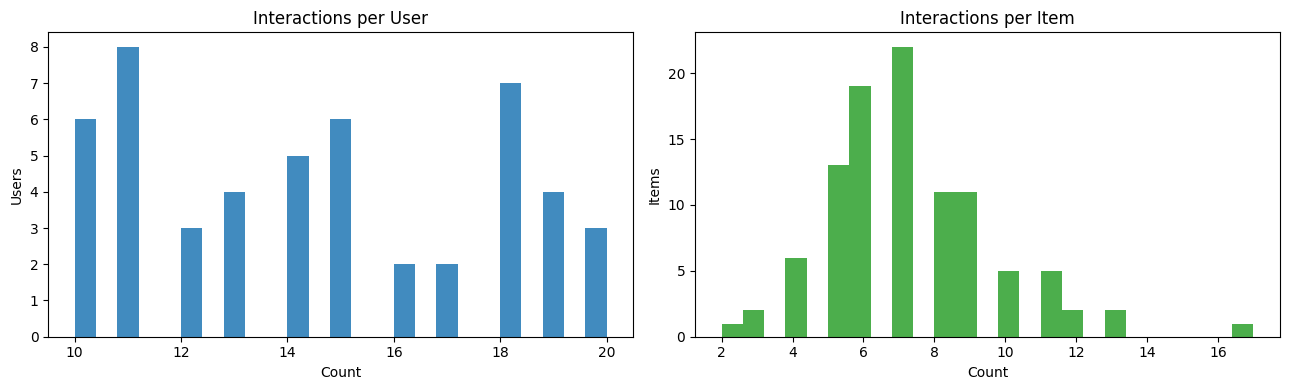

In [5]:
user_activity = (user_item_matrix_filled > 0).sum(axis=1)
item_popularity = (user_item_matrix_filled > 0).sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(user_activity, bins=25, color='#1f77b4', alpha=0.85)
axes[0].set_title('Interactions per User')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Users')

axes[1].hist(item_popularity, bins=25, color='#2ca02c', alpha=0.85)
axes[1].set_title('Interactions per Item')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Items')

plt.tight_layout()
plt.show()

## 3) Long-Tail Analysis

In [6]:
item_counts = item_popularity.sort_values(ascending=False)
top_10pct_n = max(1, int(np.ceil(0.10 * len(item_counts))))
top_10pct_items = set(item_counts.head(top_10pct_n).index)
head_interactions = int(item_counts.head(top_10pct_n).sum())
tail_interactions = int(item_counts.iloc[top_10pct_n:].sum())

long_tail_summary = pd.DataFrame({
    'Metric': [
        'Top10PctItemsCount',
        'Top10PctItemsInteractionShare',
        'Bottom90PctItemsInteractionShare',
    ],
    'Value': [
        top_10pct_n,
        head_interactions / max(1, head_interactions + tail_interactions),
        tail_interactions / max(1, head_interactions + tail_interactions),
    ],
})
long_tail_summary

,Metric,Value
0,Top10PctItemsCount,10.000000
1,Top10PctItemsInteractionShare,0.168508
2,Bottom90PctItemsInteractionShare,0.831492


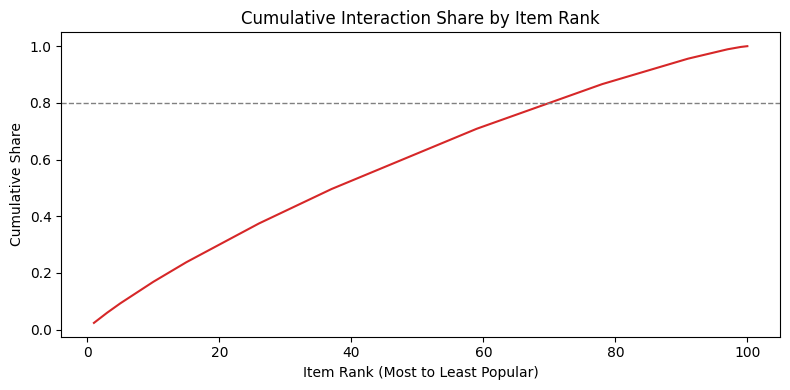

In [7]:
cum_share = item_counts.cumsum() / item_counts.sum()
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(cum_share) + 1), cum_share.values, color='#d62728')
plt.axhline(0.8, linestyle='--', color='gray', linewidth=1)
plt.title('Cumulative Interaction Share by Item Rank')
plt.xlabel('Item Rank (Most to Least Popular)')
plt.ylabel('Cumulative Share')
plt.tight_layout()
plt.show()

## 4) Temporal and Category Trends

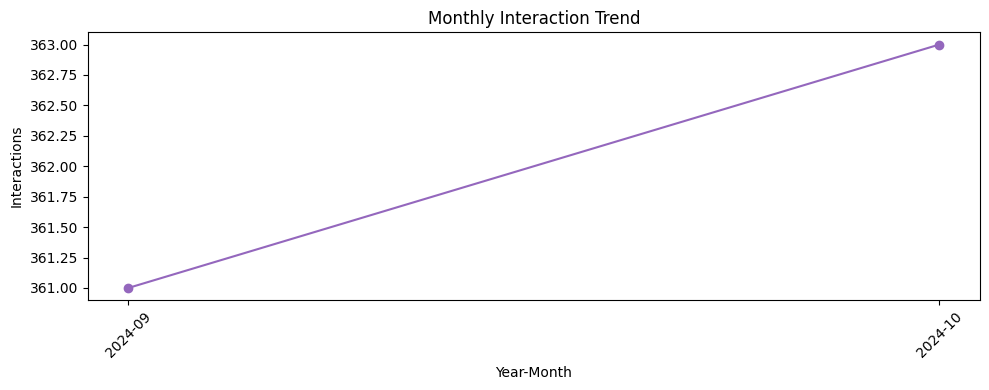

,YearMonth,Interactions
0,2024-09,361
1,2024-10,363


In [8]:
user_data['YearMonth'] = user_data['Timestamp'].dt.to_period('M').astype(str)
monthly_interactions = user_data.groupby('YearMonth').size().reset_index(name='Interactions')

plt.figure(figsize=(10, 4))
plt.plot(monthly_interactions['YearMonth'], monthly_interactions['Interactions'], marker='o', color='#9467bd')
plt.title('Monthly Interaction Trend')
plt.xlabel('Year-Month')
plt.ylabel('Interactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_interactions.tail(12)

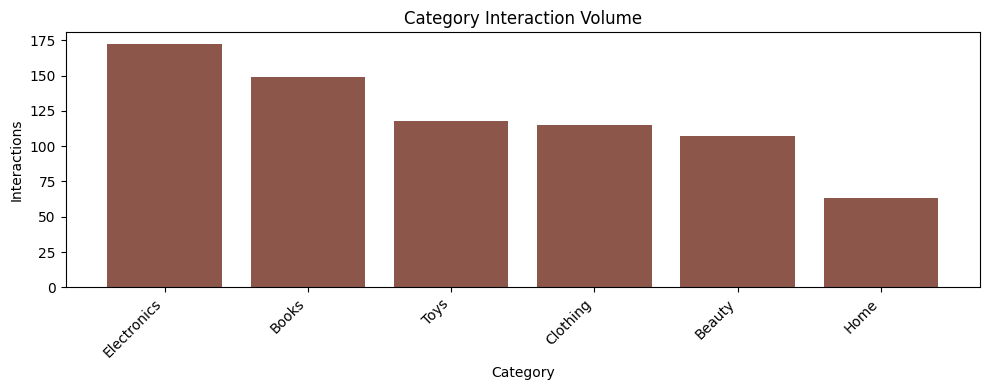

,Category,Interactions
0,Electronics,172
1,Books,149
2,Toys,118
3,Clothing,115
4,Beauty,107
5,Home,63


In [9]:
category_counts = user_data['Category'].value_counts().reset_index()
category_counts.columns = ['Category', 'Interactions']

plt.figure(figsize=(10, 4))
plt.bar(category_counts['Category'], category_counts['Interactions'], color='#8c564b')
plt.title('Category Interaction Volume')
plt.xlabel('Category')
plt.ylabel('Interactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

category_counts

## 5) User Segmentation Diagnostics

In [10]:
user_interactions = user_data.groupby('UserID').size().rename('Interactions')
q33, q66 = user_interactions.quantile([0.33, 0.66]).tolist()

def segment_user(x):
    if x <= q33:
        return 'Light'
    if x <= q66:
        return 'Medium'
    return 'Heavy'

user_segments = user_interactions.to_frame()
user_segments['Segment'] = user_segments['Interactions'].apply(segment_user)
segment_summary = user_segments['Segment'].value_counts().reset_index()
segment_summary.columns = ['Segment', 'Users']
segment_summary

,Segment,Users
0,Medium,17
1,Light,17
2,Heavy,16


In [11]:
user_primary_group = (
    user_category_agg.sort_values(['UserID', 'TotalInteractions'], ascending=[True, False])
    .drop_duplicates(subset='UserID')
    [['UserID', 'Category']]
    .rename(columns={'Category': 'PrimaryCategory'})
)

segment_with_category = user_segments.reset_index().merge(user_primary_group, on='UserID', how='left')
heat = pd.crosstab(segment_with_category['Segment'], segment_with_category['PrimaryCategory'])
heat

PrimaryCategory,Beauty,Books,Clothing,Electronics,Toys
Segment,,,,,
Heavy,1,10,1,3,1
Light,7,3,1,6,0
Medium,2,5,4,4,2


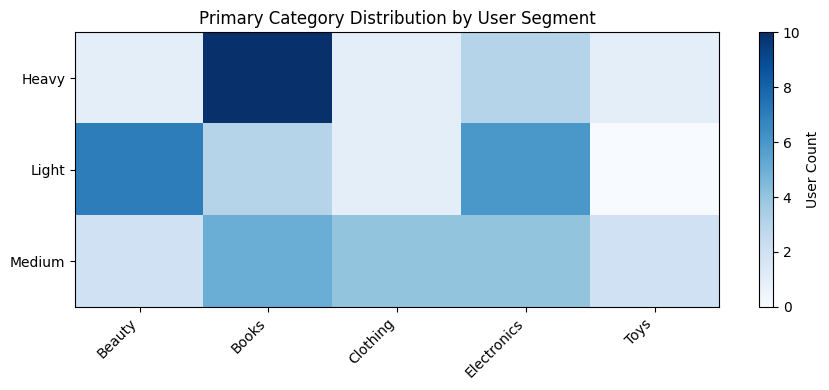

In [12]:
plt.figure(figsize=(9, 4))
plt.imshow(heat.values, cmap='Blues', aspect='auto')
plt.colorbar(label='User Count')
plt.xticks(range(len(heat.columns)), heat.columns, rotation=45, ha='right')
plt.yticks(range(len(heat.index)), heat.index)
plt.title('Primary Category Distribution by User Segment')
plt.tight_layout()
plt.show()

## Key Takeaways
- Sparsity and long-tail metrics justify collaborative filtering and diversification tracking.
- Segment diagnostics provide context for group-level recommendation strategies.
- Temporal and category trends help explain shifts in recommendation performance over time.